# Actividad en clase — GridWorld 15x15 con Reinforcement Learning

**Objetivo:** trazar el mejor camino entre un punto de **inicio** y un punto **final** en una
cuadrícula de 15x15 con 5 obstáculos, usando:

1. **Método de valores** (*Value Iteration*): calcula $V(s)$ resolviendo la ecuación de Bellman
   y de allí se deriva la **política de dirección** (una flecha por celda).
2. **Q-Learning** (RL libre de modelo): el agente aprende $Q(s,a)$ por ensayo y error,
   sin conocer las reglas del entorno.

En ambos casos se **muestran las iteraciones** y el avance del aprendizaje.

## 1. El entorno: cuadrícula 15x15

- **Estados:** las 225 celdas $(fila, columna)$.
- **Acciones:** $\uparrow$, $\downarrow$, $\leftarrow$, $\rightarrow$ (política de dirección).
- **Recompensas:** $-1$ por cada paso (para premiar caminos cortos), $+100$ al llegar a la meta,
  y $-10$ si se choca contra un obstáculo o una pared (el agente se queda en su lugar).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

N = 15                       # tamaño de la cuadrícula
START = (0, 0)               # inicio
GOAL = (14, 14)              # final
OBSTACLES = [(3, 3), (7, 7), (10, 4), (5, 11), (12, 9)]   # 5 obstáculos

ACTIONS = {'arriba': (-1, 0), 'abajo': (1, 0), 'izquierda': (0, -1), 'derecha': (0, 1)}
A_NAMES = list(ACTIONS.keys())
ARROWS = {'arriba': '↑', 'abajo': '↓', 'izquierda': '←', 'derecha': '→'}

R_STEP, R_GOAL, R_CRASH = -1.0, 100.0, -10.0

obstacle_set = set(OBSTACLES)


def dentro(s):
    i, j = s
    return 0 <= i < N and 0 <= j < N


def transicion(s, a_name):
    """Modelo del entorno: devuelve (s_siguiente, recompensa, terminado)."""
    di, dj = ACTIONS[a_name]
    s2 = (s[0] + di, s[1] + dj)
    if not dentro(s2) or s2 in obstacle_set:
        return s, R_CRASH, False          # choque: no se mueve
    if s2 == GOAL:
        return s2, R_GOAL, True
    return s2, R_STEP, False


ESTADOS = [(i, j) for i in range(N) for j in range(N)
           if (i, j) not in obstacle_set]

print(f'Cuadrícula {N}x{N} | estados válidos: {len(ESTADOS)}')
print(f'Inicio: {START}  Final: {GOAL}')
print(f'Obstáculos: {OBSTACLES}')

Cuadrícula 15x15 | estados válidos: 220
Inicio: (0, 0)  Final: (14, 14)
Obstáculos: [(3, 3), (7, 7), (10, 4), (5, 11), (12, 9)]


### Utilidades de visualización

Un solo mapa secuencial (un tono, claro → oscuro) para la magnitud de $V(s)$; los obstáculos
van en gris neutro y el inicio/final se identifican **con texto**, no solo con color.

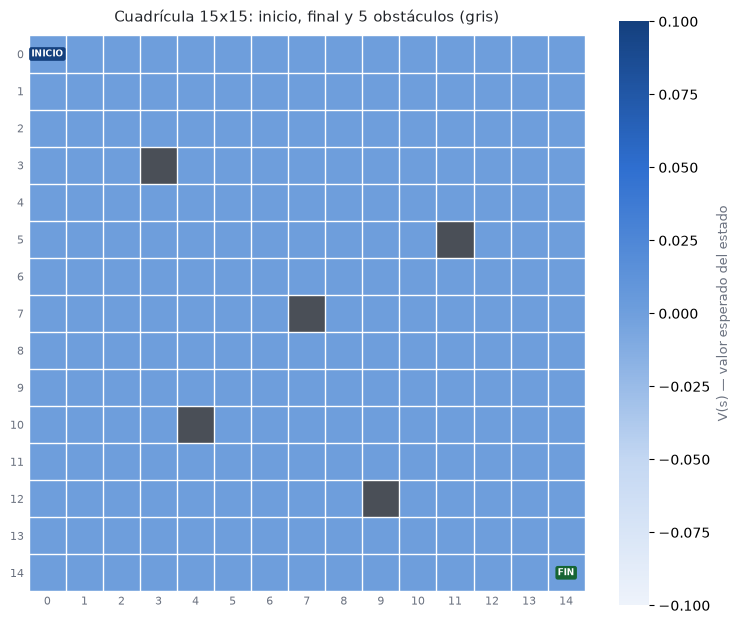

In [2]:
CMAP = LinearSegmentedColormap.from_list(
    'valores', ['#eef3fb', '#c3d7f2', '#6f9fdd', '#2f6fd0', '#14407e'])
GRIS_OBST = '#4a4f57'
TINTA = '#22252a'
TINTA_SUAVE = '#6b7280'


def dibujar_grid(V, politica=None, camino=None, titulo='', ax=None, mostrar_flechas=True):
    creado = ax is None
    if creado:
        fig, ax = plt.subplots(figsize=(7.6, 7.6))

    M = np.array(V, dtype=float).copy()
    for o in OBSTACLES:
        M[o] = np.nan

    cmap = CMAP.copy()
    cmap.set_bad(GRIS_OBST)
    im = ax.imshow(M, cmap=cmap, origin='upper')

    # rejilla recesiva
    ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.0)
    ax.set_xticks(range(N)); ax.set_yticks(range(N))
    ax.tick_params(which='both', length=0, labelsize=8, colors=TINTA_SUAVE)
    for lado in ax.spines.values():
        lado.set_visible(False)

    # política de dirección: una flecha por celda
    if politica is not None and mostrar_flechas:
        for (i, j) in ESTADOS:
            if (i, j) == GOAL:
                continue
            a = politica[i][j]
            if a is None:
                continue
            ax.text(j, i, ARROWS[a], ha='center', va='center',
                    fontsize=9, color=TINTA, alpha=0.75)

    # camino trazado
    if camino:
        ys = [p[0] for p in camino]; xs = [p[1] for p in camino]
        ax.plot(xs, ys, color='#c2410c', linewidth=2.0, solid_capstyle='round', zorder=3)
        ax.plot(xs, ys, 'o', color='#c2410c', markersize=3.5, zorder=4)

    ax.text(START[1], START[0], 'INICIO', ha='center', va='center', fontsize=6.5,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.25', fc='#14407e', ec='none'), zorder=5)
    ax.text(GOAL[1], GOAL[0], 'FIN', ha='center', va='center', fontsize=6.5,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.25', fc='#166534', ec='none'), zorder=5)

    ax.set_title(titulo, fontsize=11, color=TINTA, pad=10)
    if creado:
        cb = fig.colorbar(im, ax=ax, shrink=0.8)
        cb.set_label('V(s) — valor esperado del estado', fontsize=9, color=TINTA_SUAVE)
        cb.outline.set_visible(False)
        plt.tight_layout()
        plt.show()
    return im


dibujar_grid(np.zeros((N, N)),
             titulo='Cuadrícula 15x15: inicio, final y 5 obstáculos (gris)')

## 2. Método de valores — *Value Iteration*

Se aplica repetidamente la ecuación de optimalidad de Bellman hasta que los valores dejan de cambiar:

$$V_{k+1}(s) \leftarrow \max_a \big[\, r(s,a) + \gamma\, V_k(s')\, \big]$$

Se imprime en cada iteración el cambio máximo $\Delta = \max_s |V_{k+1}(s) - V_k(s)|$
y el valor del estado inicial.

In [3]:
GAMMA = 0.95
THETA = 1e-4
MAX_ITER = 500

V = np.zeros((N, N))
hist_delta = []
snapshots = {}                 # iteración -> copia de V (para ver el avance)
GUARDAR_EN = [1, 3, 10, 30]
ITER_FINAL = MAX_ITER

print(f'{"iter":>5} | {"delta":>10} | {"V(inicio)":>10}')
print('-' * 32)

for it in range(1, MAX_ITER + 1):
    V_new = V.copy()
    delta = 0.0
    for s in ESTADOS:
        if s == GOAL:
            continue
        mejor = max(r + GAMMA * V[s2] for s2, r, _ in
                    (transicion(s, a) for a in A_NAMES))
        V_new[s] = mejor
        delta = max(delta, abs(mejor - V[s]))
    V = V_new
    hist_delta.append(delta)

    if it in GUARDAR_EN:
        snapshots[it] = V.copy()
    if it <= 10 or it % 10 == 0:
        print(f'{it:>5} | {delta:>10.5f} | {V[START]:>10.3f}')

    if delta < THETA:
        ITER_FINAL = it
        snapshots[it] = V.copy()
        print(f'\nConvergió en la iteración {it} (delta = {delta:.2e})')
        break

print(f'V(inicio) = {V[START]:.3f}   V(vecino del final) = {V[13, 14]:.3f}')

 iter |      delta |  V(inicio)
--------------------------------
    1 |  100.00000 |     -1.000
    2 |   95.00000 |     -1.950
    3 |   90.25000 |     -2.853
    4 |   85.73750 |     -3.710
    5 |   81.45062 |     -4.524
    6 |   77.37809 |     -5.298
    7 |   73.50919 |     -6.033
    8 |   69.83373 |     -6.732
    9 |   66.34204 |     -7.395
   10 |   63.02494 |     -8.025
   20 |   37.73536 |    -12.830

Convergió en la iteración 29 (delta = 0.00e+00)
V(inicio) = 10.041   V(vecino del final) = 100.000


### Política de dirección derivada de los valores

Para cada celda se elige la acción que maximiza $r + \gamma V(s')$: eso produce **una flecha por celda**.

Longitud del camino: 28 pasos  (distancia Manhattan inicio-final: 28)
Camino: (0, 0) -> (1, 0) -> (2, 0) -> (3, 0) -> (4, 0) -> (5, 0) -> (6, 0) -> (7, 0) -> (8, 0) -> (9, 0) -> (10, 0) -> (11, 0) -> (12, 0) -> (13, 0) -> (14, 0) -> (14, 1) -> (14, 2) -> (14, 3) -> (14, 4) -> (14, 5) -> (14, 6) -> (14, 7) -> (14, 8) -> (14, 9) -> (14, 10) -> (14, 11) -> (14, 12) -> (14, 13) -> (14, 14)


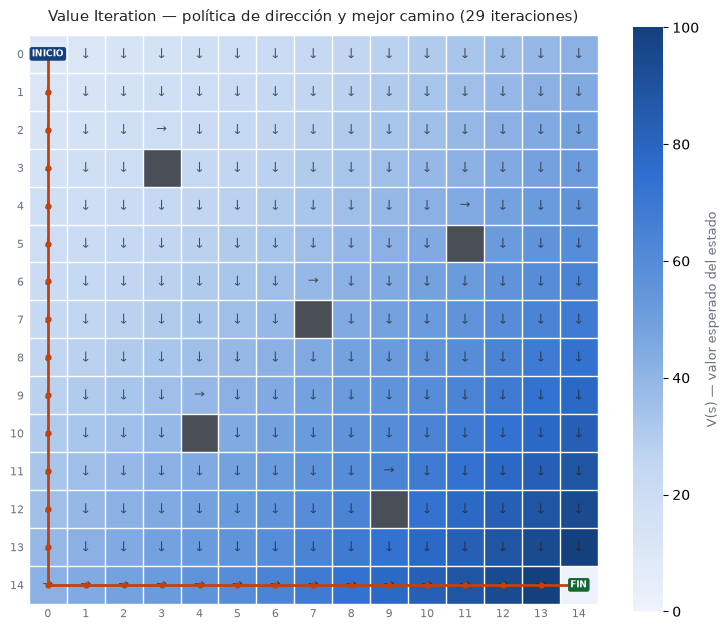

In [4]:
def politica_desde_valores(V):
    pol = [[None] * N for _ in range(N)]
    for s in ESTADOS:
        if s == GOAL:
            continue
        mejor_a, mejor_q = None, -np.inf
        for a in A_NAMES:
            s2, r, _ = transicion(s, a)
            q = r + GAMMA * V[s2]
            if q > mejor_q:
                mejor_q, mejor_a = q, a
        pol[s[0]][s[1]] = mejor_a
    return pol


def trazar_camino(politica, max_pasos=300):
    s, camino, visitados = START, [START], {START}
    for _ in range(max_pasos):
        if s == GOAL:
            break
        a = politica[s[0]][s[1]]
        if a is None:
            break
        s2, _, _ = transicion(s, a)
        if s2 == s or s2 in visitados:      # atascado o en ciclo
            break
        s = s2
        visitados.add(s)
        camino.append(s)
    return camino


POL_VI = politica_desde_valores(V)
CAMINO_VI = trazar_camino(POL_VI)

print(f'Longitud del camino: {len(CAMINO_VI) - 1} pasos  '
      f'(distancia Manhattan inicio-final: {(N - 1) * 2})')
print('Camino:', ' -> '.join(str(p) for p in CAMINO_VI))

dibujar_grid(V, POL_VI, CAMINO_VI,
             titulo=f'Value Iteration — política de dirección y mejor camino '
                    f'({ITER_FINAL} iteraciones)')

### Avance de las iteraciones

El valor se propaga desde la meta hacia atrás: en la iteración 1 solo las celdas vecinas al final
"saben algo"; iteración tras iteración la información llega hasta el inicio.

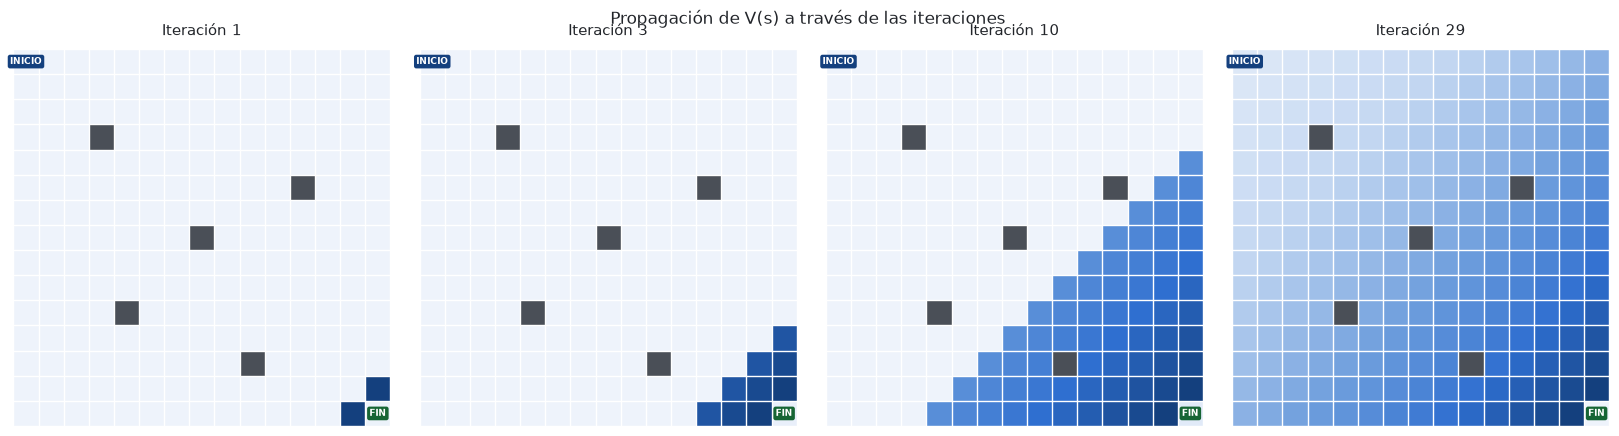

In [5]:
its = sorted(snapshots.keys())[:4]
fig, axes = plt.subplots(1, len(its), figsize=(4.1 * len(its), 4.4))
for ax, it in zip(np.atleast_1d(axes), its):
    Vi = snapshots[it]
    dibujar_grid(Vi, None, None, titulo=f'Iteración {it}', ax=ax)
    ax.set_xticklabels([]); ax.set_yticklabels([])
fig.suptitle('Propagación de V(s) a través de las iteraciones', fontsize=12, color=TINTA)
plt.tight_layout()
plt.show()

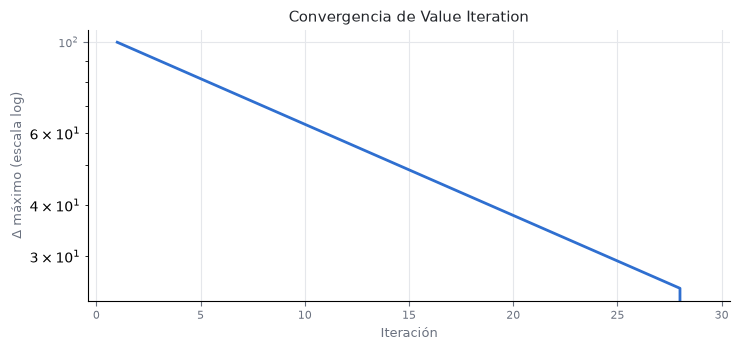

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(range(1, len(hist_delta) + 1), hist_delta, color='#2f6fd0', linewidth=2.0)
ax.set_yscale('log')
ax.set_xlabel('Iteración', fontsize=9, color=TINTA_SUAVE)
ax.set_ylabel('Δ máximo (escala log)', fontsize=9, color=TINTA_SUAVE)
ax.set_title('Convergencia de Value Iteration', fontsize=11, color=TINTA)
ax.grid(color='#e5e7eb', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(labelsize=8, colors=TINTA_SUAVE)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
ax.annotate(f'convergencia: iter {ITER_FINAL}',
            xy=(ITER_FINAL, hist_delta[-1]), xytext=(-115, 22),
            textcoords='offset points', fontsize=8.5, color=TINTA,
            arrowprops=dict(arrowstyle='-', color=TINTA_SUAVE, linewidth=0.9))
plt.tight_layout()
plt.show()

## 3. Reinforcement Learning — Q-Learning

Ahora el agente **no conoce el modelo**: solo actúa, observa y aprende con

$$Q(s,a) \leftarrow Q(s,a) + \alpha\Big[\, r + \gamma \max_{a'} Q(s',a') - Q(s,a) \,\Big]$$

con exploración $\varepsilon$-greedy y $\varepsilon$ decayendo con los episodios.

In [7]:
EPISODIOS = 4000
ALPHA = 0.1
GAMMA_Q = 0.95
EPS_INI, EPS_MIN, EPS_DECAY = 1.0, 0.02, 0.999
MAX_PASOS = 400

Q = np.zeros((N, N, len(A_NAMES)))
eps = EPS_INI
rec_por_ep, pasos_por_ep, eps_hist = [], [], []
snap_Q = {}
GUARDAR_EP = [50, 200, 1000, EPISODIOS]


def politica_desde_Q(Q):
    pol = [[None] * N for _ in range(N)]
    for (i, j) in ESTADOS:
        if (i, j) == GOAL:
            continue
        pol[i][j] = A_NAMES[int(np.argmax(Q[i, j]))]
    return pol


print(f'{"episodio":>9} | {"epsilon":>7} | {"recompensa":>10} | {"pasos":>6} | {"llegó":>5}')
print('-' * 52)

for ep in range(1, EPISODIOS + 1):
    s = START
    total_r, pasos, llego = 0.0, 0, False

    for _ in range(MAX_PASOS):
        if np.random.rand() < eps:
            ai = np.random.randint(len(A_NAMES))            # explorar
        else:
            ai = int(np.argmax(Q[s[0], s[1]]))              # explotar

        s2, r, fin = transicion(s, A_NAMES[ai])
        objetivo = r if fin else r + GAMMA_Q * np.max(Q[s2[0], s2[1]])
        Q[s[0], s[1], ai] += ALPHA * (objetivo - Q[s[0], s[1], ai])

        s, total_r, pasos = s2, total_r + r, pasos + 1
        if fin:
            llego = True
            break

    eps = max(EPS_MIN, eps * EPS_DECAY)
    rec_por_ep.append(total_r); pasos_por_ep.append(pasos); eps_hist.append(eps)

    if ep in GUARDAR_EP:
        snap_Q[ep] = Q.copy()
    if ep <= 5 or ep % 250 == 0:
        print(f'{ep:>9} | {eps:>7.3f} | {total_r:>10.1f} | {pasos:>6} | '
              f'{"sí" if llego else "no":>5}')

POL_Q = politica_desde_Q(Q)
CAMINO_Q = trazar_camino(POL_Q)
print(f'\nCamino aprendido por Q-Learning: {len(CAMINO_Q) - 1} pasos'
      f'  |  Value Iteration: {len(CAMINO_VI) - 1} pasos')

 episodio | epsilon | recompensa |  pasos | llegó
----------------------------------------------------
        1 |   0.999 |    -1030.0 |    400 |    no
        2 |   0.998 |     -778.0 |    400 |    no
        3 |   0.997 |     -715.0 |    400 |    no
        4 |   0.996 |     -688.0 |    400 |    no
        5 |   0.995 |     -415.0 |    282 |    sí


      250 |   0.779 |      -43.0 |     90 |    sí


      500 |   0.606 |       39.0 |     53 |    sí


      750 |   0.472 |       17.0 |     57 |    sí


     1000 |   0.368 |       47.0 |     54 |    sí


...

     2250 |   0.105 |       71.0 |     30 |    sí


     2500 |   0.082 |       71.0 |     30 |    sí


     2750 |   0.064 |       63.0 |     29 |    sí


     3000 |   0.050 |       61.0 |     31 |    sí
     3250 |   0.039 |       73.0 |     28 |    sí


     3500 |   0.030 |       71.0 |     30 |    sí
     3750 |   0.023 |       73.0 |     28 |    sí
     4000 |   0.020 |       71.0 |     30 |    sí

Camino aprendido por Q-Learning: 28 pasos  |  Value Iteration: 28 pasos


### Avance del aprendizaje (RL)

Media móvil de la recompensa y de los pasos por episodio: el agente pasa de vagar al azar
a resolver la cuadrícula en el mínimo número de pasos.

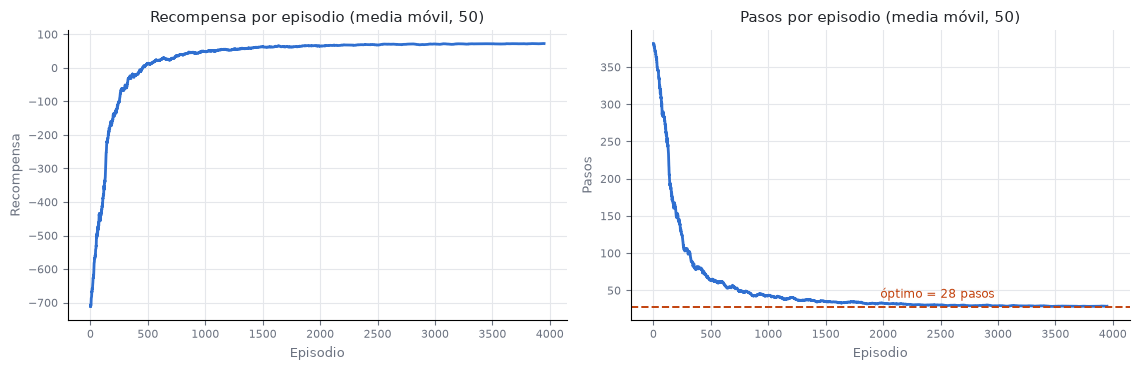

In [8]:
def media_movil(x, k=50):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode='valid')


fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

y = media_movil(rec_por_ep)
axes[0].plot(range(len(y)), y, color='#2f6fd0', linewidth=2.0)
axes[0].set_title('Recompensa por episodio (media móvil, 50)', fontsize=11, color=TINTA)
axes[0].set_ylabel('Recompensa', fontsize=9, color=TINTA_SUAVE)

y = media_movil(pasos_por_ep)
optimo = len(CAMINO_VI) - 1
axes[1].plot(range(len(y)), y, color='#2f6fd0', linewidth=2.0)
axes[1].axhline(optimo, color='#c2410c', linewidth=1.4, linestyle='--')
axes[1].text(len(y) * 0.5, optimo + 12, f'óptimo = {optimo} pasos',
             fontsize=8.5, color='#c2410c')
axes[1].set_title('Pasos por episodio (media móvil, 50)', fontsize=11, color=TINTA)
axes[1].set_ylabel('Pasos', fontsize=9, color=TINTA_SUAVE)

for eje in axes:
    eje.set_xlabel('Episodio', fontsize=9, color=TINTA_SUAVE)
    eje.grid(color='#e5e7eb', linewidth=0.8)
    eje.set_axisbelow(True)
    eje.tick_params(labelsize=8, colors=TINTA_SUAVE)
    for lado in ('top', 'right'):
        eje.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

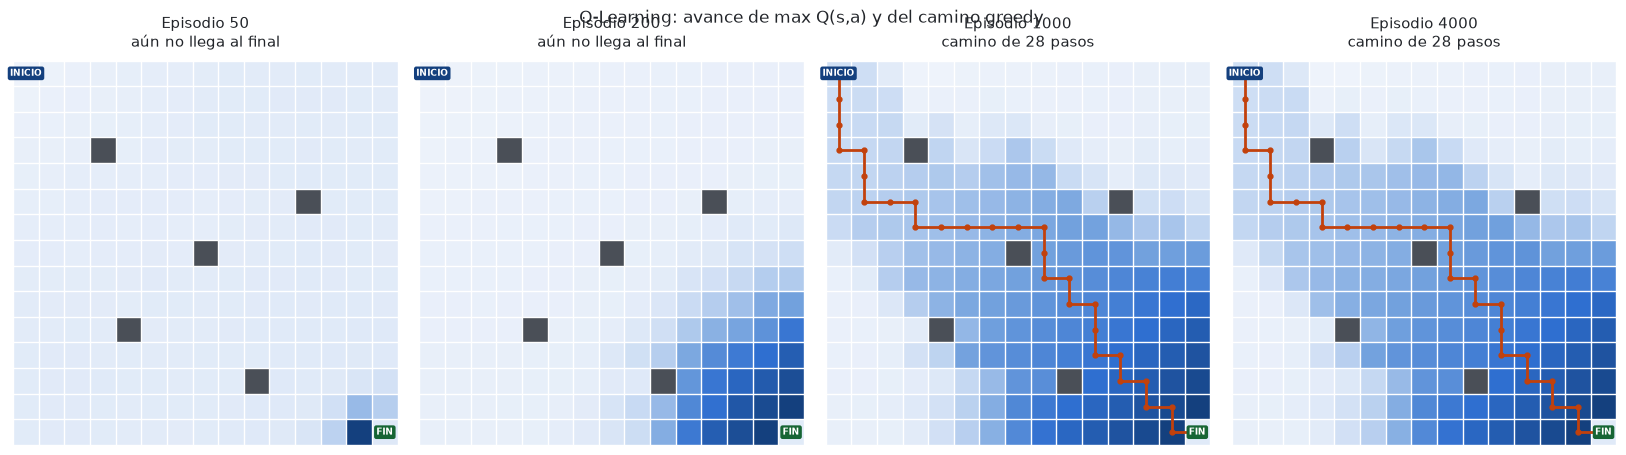

In [9]:
eps_snaps = sorted(snap_Q.keys())
fig, axes = plt.subplots(1, len(eps_snaps), figsize=(4.1 * len(eps_snaps), 4.7))
for ax, ep in zip(np.atleast_1d(axes), eps_snaps):
    Qe = snap_Q[ep]
    pol = politica_desde_Q(Qe)
    cam = trazar_camino(pol)
    ok = cam[-1] == GOAL
    dibujar_grid(Qe.max(axis=2), pol, cam if ok else None,
                 titulo=f'Episodio {ep}\n' +
                        (f'camino de {len(cam) - 1} pasos' if ok else 'aún no llega al final'),
                 ax=ax, mostrar_flechas=False)
    ax.set_xticklabels([]); ax.set_yticklabels([])
fig.suptitle('Q-Learning: avance de max Q(s,a) y del camino greedy', fontsize=12, color=TINTA)
plt.tight_layout()
plt.show()

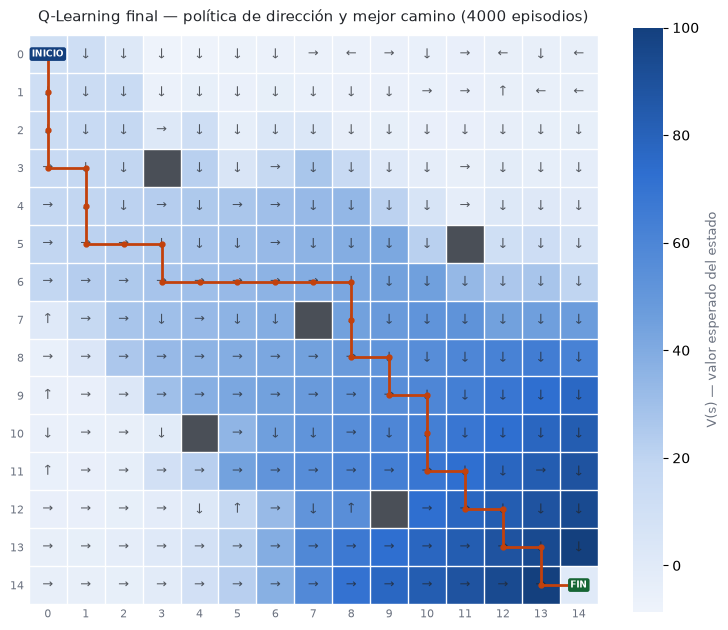

In [10]:
dibujar_grid(Q.max(axis=2), POL_Q, CAMINO_Q,
             titulo=f'Q-Learning final — política de dirección y mejor camino '
                    f'({EPISODIOS} episodios)')

## 4. Comparación de los dos métodos

Método                iteraciones   pasos del camino
----------------------------------------------------
Value Iteration                29                 28
Q-Learning                   4000                 28

Coincidencia de políticas de dirección: 131/219 celdas (59.8%)
Nota: lejos del camino óptimo hay varias acciones igual de buenas, por eso las
flechas pueden diferir sin que el camino final cambie.


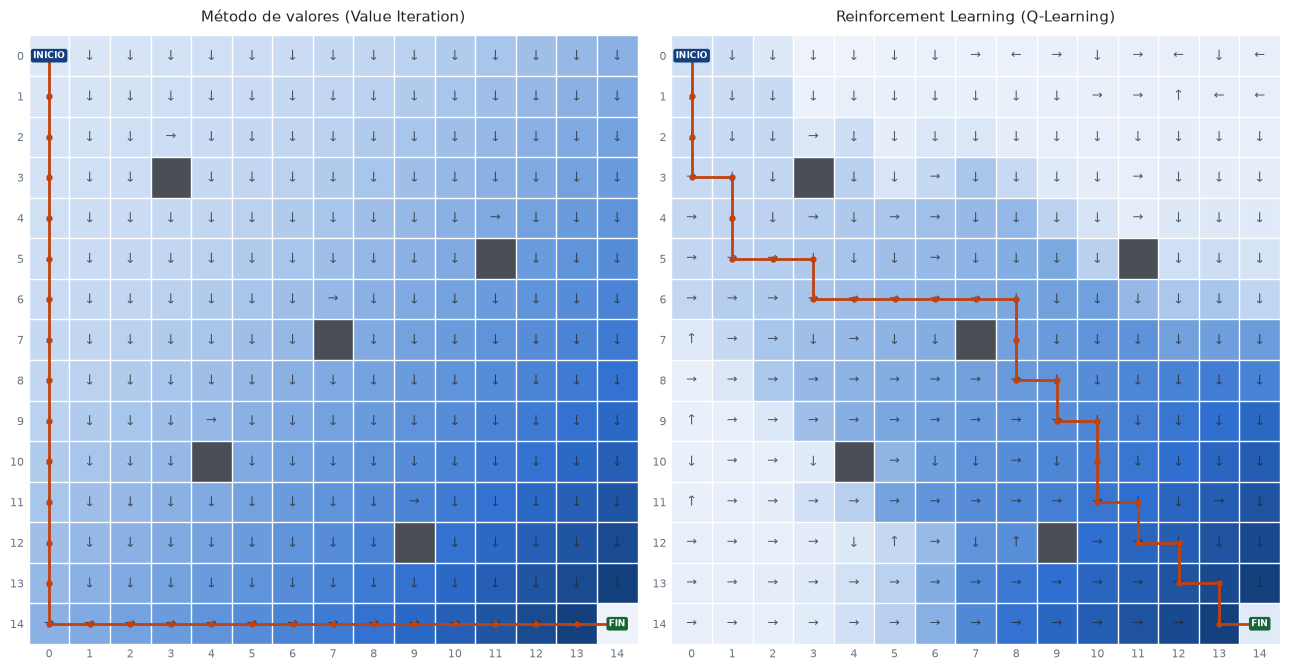

In [11]:
iguales = sum(1 for (i, j) in ESTADOS
              if (i, j) != GOAL and POL_VI[i][j] == POL_Q[i][j])
total = len(ESTADOS) - 1

print(f'{"Método":<20}{"iteraciones":>13}{"pasos del camino":>19}')
print('-' * 52)
print(f'{"Value Iteration":<20}{ITER_FINAL:>13}{len(CAMINO_VI) - 1:>19}')
print(f'{"Q-Learning":<20}{EPISODIOS:>13}{len(CAMINO_Q) - 1:>19}')
print(f'\nCoincidencia de políticas de dirección: {iguales}/{total} celdas '
      f'({100 * iguales / total:.1f}%)')
print('Nota: lejos del camino óptimo hay varias acciones igual de buenas, por eso las\n'
      'flechas pueden diferir sin que el camino final cambie.')

fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
dibujar_grid(V, POL_VI, CAMINO_VI, titulo='Método de valores (Value Iteration)', ax=axes[0])
dibujar_grid(Q.max(axis=2), POL_Q, CAMINO_Q,
             titulo='Reinforcement Learning (Q-Learning)', ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Conclusiones parciales (valores vs. Q-Learning)

- El **método de valores** usa el modelo del entorno y converge en pocas decenas de barridos;
  la política de dirección sale directo de $V(s)$.
- **Q-Learning** llega al mismo camino sin conocer el modelo, pero necesita miles de episodios
  de exploración; la curva de pasos por episodio muestra ese aprendizaje.
- Ambos coinciden en el **mejor camino** entre inicio y final, esquivando los 5 obstáculos.

**Para experimentar:** mueve los obstáculos para formar un muro que obligue a rodear, cambia
`GAMMA`, `ALPHA` o `EPS_DECAY`, o agrega recompensas negativas en zonas de "riesgo".

## 6. Q-Learning frente a los métodos previos

La política de Q-Learning ya está entrenada arriba. Falta lo importante: **ponerla al lado de los
métodos que vimos antes en el curso**, sobre exactamente la misma cuadrícula 15x15.

| Método | Clase | ¿Necesita el modelo del entorno? |
|---|---|---|
| BFS | Búsqueda no informada (clase 2) | sí, el mapa completo |
| A* (Manhattan) | Búsqueda informada (clase 2) | sí, mapa + heurística |
| Value Iteration | MDP (clase 4) | sí, $r(s,a)$ y $s'$ |
| Policy Iteration | MDP (clase 4) | sí, $r(s,a)$ y $s'$ |
| **Q-Learning** | **RL libre de modelo (clase 5)** | **no, solo experiencia** |

Comparamos tres cosas: **calidad del camino** (pasos), **costo de cómputo** (nodos expandidos,
barridos o interacciones con el entorno) y **qué información exige cada método**.

In [12]:
from collections import deque
import heapq
import time

VECINOS = lambda s: [(a, transicion(s, a)[0]) for a in A_NAMES]


def bfs():
    """Búsqueda en anchura (clase 2): óptima en pasos, pero necesita ver el mapa completo."""
    frontera = deque([START])
    padre = {START: None}
    expandidos = 0
    while frontera:
        s = frontera.popleft()
        expandidos += 1
        if s == GOAL:
            break
        for _, s2 in VECINOS(s):
            if s2 != s and s2 not in padre:
                padre[s2] = s
                frontera.append(s2)
    camino, s = [], GOAL
    while s is not None:
        camino.append(s); s = padre[s]
    return camino[::-1], expandidos


def a_estrella():
    """A* con heurística Manhattan (clase 2). Admisible: nunca sobreestima el costo restante."""
    h = lambda s: abs(s[0] - GOAL[0]) + abs(s[1] - GOAL[1])
    abierta = [(h(START), 0, START)]     # (f, -g, s): ante empates avanza el nodo más profundo
    g = {START: 0}
    padre = {START: None}
    expandidos = 0
    while abierta:
        _, mgs, s = heapq.heappop(abierta)
        gs = -mgs
        if gs > g.get(s, np.inf):        # entrada obsoleta del heap
            continue
        expandidos += 1
        if s == GOAL:
            break
        for _, s2 in VECINOS(s):
            if s2 == s:
                continue
            if gs + 1 < g.get(s2, np.inf):
                g[s2] = gs + 1
                padre[s2] = s
                heapq.heappush(abierta, (gs + 1 + h(s2), -(gs + 1), s2))
    camino, s = [], GOAL
    while s is not None:
        camino.append(s); s = padre[s]
    return camino[::-1], expandidos


t0 = time.perf_counter(); CAMINO_BFS, EXP_BFS = bfs();       T_BFS = time.perf_counter() - t0
t0 = time.perf_counter(); CAMINO_AST, EXP_AST = a_estrella(); T_AST = time.perf_counter() - t0

OPTIMO = len(CAMINO_BFS) - 1          # BFS garantiza el mínimo número de pasos
print(f'BFS: {OPTIMO:>3} pasos | {EXP_BFS:>4} nodos expandidos | {T_BFS*1000:.1f} ms')
print(f'A* : {len(CAMINO_AST)-1:>3} pasos | {EXP_AST:>4} nodos expandidos | {T_AST*1000:.1f} ms')
print(f'\nLa heurística Manhattan reduce la expansión de {EXP_BFS} a {EXP_AST} nodos '
      f'({100*(1-EXP_AST/EXP_BFS):.0f}% menos).')

BFS:  28 pasos |  220 nodos expandidos | 0.4 ms
A* :  28 pasos |   29 nodos expandidos | 0.1 ms

La heurística Manhattan reduce la expansión de 220 a 29 nodos (87% menos).


In [13]:
def policy_iteration():
    """Policy Iteration (clase 4): alterna evaluación de la política y mejora, hasta que se estabiliza."""
    pol = {s: A_NAMES[0] for s in ESTADOS if s != GOAL}      # política inicial arbitraria
    Vp = np.zeros((N, N))
    iteraciones, barridos = 0, 0

    while True:
        iteraciones += 1

        while True:                                          # --- evaluación de la política ---
            barridos += 1
            delta = 0.0
            for s in ESTADOS:
                if s == GOAL:
                    continue
                s2, r, _ = transicion(s, pol[s])
                v = r + GAMMA * Vp[s2]
                delta = max(delta, abs(v - Vp[s]))
                Vp[s] = v
            if delta < THETA:
                break

        estable = True                                       # --- mejora de la política ---
        for s in ESTADOS:
            if s == GOAL:
                continue
            mejor_a, mejor_q = pol[s], -np.inf
            for a in A_NAMES:
                s2, r, _ = transicion(s, a)
                q = r + GAMMA * Vp[s2]
                if q > mejor_q:
                    mejor_q, mejor_a = q, a
            if mejor_a != pol[s]:
                estable = False
                pol[s] = mejor_a

        print(f'iteración {iteraciones}: {barridos:>3} barridos acumulados | '
              f'V(inicio) = {Vp[START]:.3f} | {"política estable" if estable else "política cambió"}')
        if estable:
            break

    rejilla = [[None] * N for _ in range(N)]
    for s, a in pol.items():
        rejilla[s[0]][s[1]] = a
    return Vp, rejilla, iteraciones, barridos


t0 = time.perf_counter()
V_PI, POL_PI, IT_PI, BARR_PI = policy_iteration()
T_PI = time.perf_counter() - t0
CAMINO_PI = trazar_camino(POL_PI)

print(f'\nPolicy Iteration: {len(CAMINO_PI)-1} pasos | {IT_PI} iteraciones de política '
      f'| {BARR_PI} barridos | {T_PI*1000:.0f} ms')
print(f'Value Iteration : {len(CAMINO_VI)-1} pasos | {ITER_FINAL} barridos')

iteración 1: 226 barridos acumulados | V(inicio) = -199.998 | política cambió
iteración 2: 346 barridos acumulados | V(inicio) = -20.001 | política cambió
iteración 3: 349 barridos acumulados | V(inicio) = -20.001 | política cambió
iteración 4: 352 barridos acumulados | V(inicio) = -20.000 | política cambió
iteración 5: 369 barridos acumulados | V(inicio) = -20.000 | política cambió
iteración 6: 391 barridos acumulados | V(inicio) = 10.041 | política cambió
iteración 7: 392 barridos acumulados | V(inicio) = 10.041 | política estable

Policy Iteration: 28 pasos | 7 iteraciones de política | 392 barridos | 72 ms
Value Iteration : 28 pasos | 29 barridos


In [14]:
def entrenar_q(episodios=2000, alpha=0.1, gamma=0.95, eps_decay=0.999,
               eps_min=0.02, max_pasos=400, semilla=0):
    """Q-Learning parametrizable. Devuelve métricas para comparar, no solo la Q final.

    ep_optimo    = primer episodio en el que la política greedy ya traza el camino óptimo
    interacciones = pasos totales dados en el entorno (el costo real del RL)
    """
    rng = np.random.default_rng(semilla)
    Qh = np.zeros((N, N, len(A_NAMES)))
    e = 1.0
    pasos_hist, interacciones, ep_optimo = [], 0, None

    for ep in range(1, episodios + 1):
        s = START
        for k in range(max_pasos):
            if rng.random() < e:
                ai = int(rng.integers(len(A_NAMES)))
            else:
                ai = int(np.argmax(Qh[s[0], s[1]]))
            s2, r, fin = transicion(s, A_NAMES[ai])
            objetivo = r if fin else r + gamma * np.max(Qh[s2[0], s2[1]])
            Qh[s[0], s[1], ai] += alpha * (objetivo - Qh[s[0], s[1], ai])
            s = s2
            interacciones += 1
            if fin:
                break
        e = max(eps_min, e * eps_decay)
        pasos_hist.append(k + 1)

        if ep_optimo is None:                       # ¿ya es óptima la política greedy?
            cam = trazar_camino(politica_desde_Q(Qh))
            if cam[-1] == GOAL and len(cam) - 1 == OPTIMO:
                ep_optimo = ep

    return dict(Q=Qh, pasos=np.array(pasos_hist), interacciones=interacciones,
                ep_optimo=ep_optimo, camino=trazar_camino(politica_desde_Q(Qh)))


t0 = time.perf_counter()
RUN_Q = entrenar_q(episodios=EPISODIOS, alpha=ALPHA, gamma=GAMMA_Q,
                   eps_decay=EPS_DECAY, eps_min=EPS_MIN, semilla=1)
T_QL = time.perf_counter() - t0

print(f'Q-Learning ({EPISODIOS} episodios): camino de {len(RUN_Q["camino"])-1} pasos')
print(f'  política óptima ya alcanzada en el episodio {RUN_Q["ep_optimo"]}')
print(f'  interacciones con el entorno: {RUN_Q["interacciones"]:,} pasos | {T_QL:.1f} s')
print(f'  frente a los {EXP_AST} nodos que A* necesitó expandir: '
      f'{RUN_Q["interacciones"]/EXP_AST:,.0f}x más trabajo por no conocer el modelo.')

Q-Learning (4000 episodios): camino de 28 pasos
  política óptima ya alcanzada en el episodio 147
  interacciones con el entorno: 215,400 pasos | 1.1 s
  frente a los 29 nodos que A* necesitó expandir: 7,428x más trabajo por no conocer el modelo.


### El precio de no conocer el modelo: ¿cuánta experiencia hace falta?

Los métodos con modelo son deterministas: siempre dan el mismo resultado. Q-Learning depende del
azar de la exploración, así que cada configuración se corre con **3 semillas distintas** y se
reporta el episodio en el que la política greedy ya es óptima.

configuración                                ep. óptimo (3 semillas)  interacciones
-----------------------------------------------------------------------------------


α=0.1, decay=0.999  (base)                              142, 147, 95        155,805


α=0.5, decay=0.999  (rápido)                              56, 63, 43        149,352


α=0.1, decay=0.99   (poca exploración)                 205, 355, 338         92,459


α=0.1, decay=0.9999 (mucha exploración)                120, 165, 207        540,805


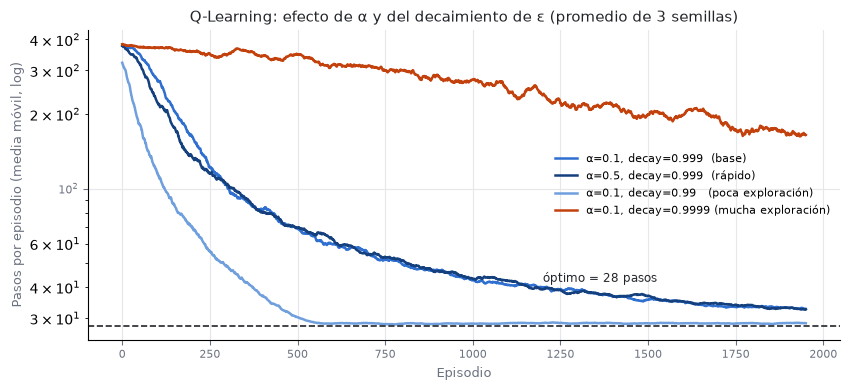

In [15]:
CONFIGS = [
    ('α=0.1, decay=0.999  (base)',   dict(alpha=0.1, eps_decay=0.999)),
    ('α=0.5, decay=0.999  (rápido)', dict(alpha=0.5, eps_decay=0.999)),
    ('α=0.1, decay=0.99   (poca exploración)',  dict(alpha=0.1, eps_decay=0.99)),
    ('α=0.1, decay=0.9999 (mucha exploración)', dict(alpha=0.1, eps_decay=0.9999)),
]
SEMILLAS = [0, 1, 2]
EPS_HP = 2000

resultados_hp = {}
print(f'{"configuración":<42}{"ep. óptimo (3 semillas)":>26}{"interacciones":>15}')
print('-' * 83)
for nombre, kw in CONFIGS:
    corridas = [entrenar_q(episodios=EPS_HP, semilla=s, **kw) for s in SEMILLAS]
    eps_opt = [c['ep_optimo'] for c in corridas]
    resultados_hp[nombre] = dict(
        eps_opt=eps_opt,
        media=np.mean([e for e in eps_opt if e is not None]) if any(e is not None for e in eps_opt) else np.nan,
        inter=int(np.mean([c['interacciones'] for c in corridas])),
        pasos=np.mean([c['pasos'] for c in corridas], axis=0))
    txt = ', '.join(str(e) if e is not None else '—' for e in eps_opt)
    print(f'{nombre:<42}{txt:>26}{resultados_hp[nombre]["inter"]:>15,}')

fig, ax = plt.subplots(figsize=(8.6, 4.0))
colores = ['#2f6fd0', '#14407e', '#6f9fdd', '#c2410c']
for (nombre, r), col in zip(resultados_hp.items(), colores):
    ax.plot(media_movil(r['pasos'], 50), color=col, linewidth=1.8, label=nombre)
ax.axhline(OPTIMO, color=TINTA, linewidth=1.2, linestyle='--')
ax.text(EPS_HP * 0.6, OPTIMO + 14, f'óptimo = {OPTIMO} pasos', fontsize=8.5, color=TINTA)
ax.set_yscale('log')
ax.set_xlabel('Episodio', fontsize=9, color=TINTA_SUAVE)
ax.set_ylabel('Pasos por episodio (media móvil, log)', fontsize=9, color=TINTA_SUAVE)
ax.set_title('Q-Learning: efecto de α y del decaimiento de ε (promedio de 3 semillas)',
             fontsize=11, color=TINTA)
ax.legend(fontsize=8, frameon=False)
ax.grid(color='#e5e7eb', linewidth=0.8); ax.set_axisbelow(True)
ax.tick_params(labelsize=8, colors=TINTA_SUAVE)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

### Tabla comparativa final

`Costo` está en la unidad natural de cada familia de métodos: **nodos expandidos** para búsqueda,
**barridos sobre los 220 estados** para los métodos de MDP e **interacciones con el entorno**
para RL. No son unidades intercambiables, y justamente eso es lo que hay que discutir.

In [16]:
Q_FINAL = RUN_Q['Q']
CAMINO_QF = RUN_Q['camino']

filas = [
    # método,           camino,          costo,                     unidad,          modelo, política global
    ('BFS',             CAMINO_BFS,      EXP_BFS,                   'nodos expand.', 'sí', 'no'),
    ('A* (Manhattan)',  CAMINO_AST,      EXP_AST,                   'nodos expand.', 'sí', 'no'),
    ('Value Iteration', CAMINO_VI,       ITER_FINAL * len(ESTADOS) * 4, 'backups',   'sí', 'sí'),
    ('Policy Iteration',CAMINO_PI,       BARR_PI * len(ESTADOS),    'backups',       'sí', 'sí'),
    ('Q-Learning',      CAMINO_QF,       RUN_Q['interacciones'],    'interacciones', 'no', 'sí'),
]

print(f'{"Método":<18}{"pasos":>7}{"óptimo":>8}{"costo":>14}  {"unidad":<15}{"modelo":>7}{"política":>10}')
print('-' * 82)
for nombre, cam, costo, unidad, modelo, glob in filas:
    pasos = len(cam) - 1
    print(f'{nombre:<18}{pasos:>7}{("sí" if pasos == OPTIMO else "no"):>8}'
          f'{costo:>14,}  {unidad:<15}{modelo:>7}{glob:>10}')

# ¿coinciden las políticas de los tres métodos que producen política global?
def coincidencia(p1, p2):
    n = sum(1 for (i, j) in ESTADOS if (i, j) != GOAL and p1[i][j] == p2[i][j])
    return n, len(ESTADOS) - 1

for etiqueta, pol in [('Policy Iteration', POL_PI), ('Q-Learning', politica_desde_Q(Q_FINAL))]:
    n, t = coincidencia(POL_VI, pol)
    print(f'\nCoincidencia con Value Iteration — {etiqueta}: {n}/{t} celdas ({100*n/t:.1f}%)')
print('\nLos cuatro métodos encuentran un camino de la misma longitud óptima; las flechas lejos')
print('del camino difieren porque allí varias acciones son igual de buenas (empates).')

Método              pasos  óptimo         costo  unidad          modelo  política
----------------------------------------------------------------------------------
BFS                    28      sí           220  nodos expand.       sí        no
A* (Manhattan)         28      sí            29  nodos expand.       sí        no
Value Iteration        28      sí        25,520  backups             sí        sí
Policy Iteration       28      sí        86,240  backups             sí        sí
Q-Learning             28      sí       215,400  interacciones       no        sí

Coincidencia con Value Iteration — Policy Iteration: 219/219 celdas (100.0%)

Coincidencia con Value Iteration — Q-Learning: 128/219 celdas (58.4%)

Los cuatro métodos encuentran un camino de la misma longitud óptima; las flechas lejos
del camino difieren porque allí varias acciones son igual de buenas (empates).


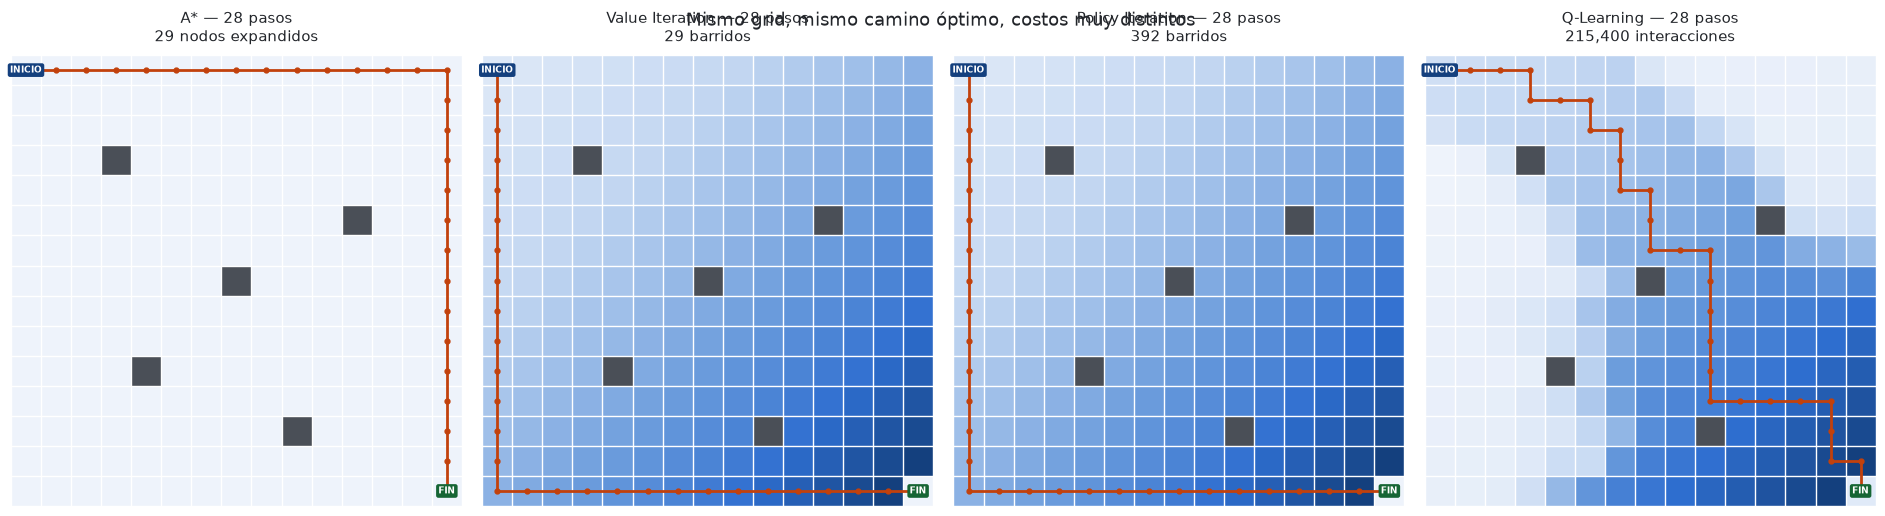

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(19, 5.2))
paneles = [
    (np.zeros((N, N)), None,   CAMINO_AST, f'A* — {len(CAMINO_AST)-1} pasos\n{EXP_AST} nodos expandidos'),
    (V,                POL_VI, CAMINO_VI,  f'Value Iteration — {len(CAMINO_VI)-1} pasos\n{ITER_FINAL} barridos'),
    (V_PI,             POL_PI, CAMINO_PI,  f'Policy Iteration — {len(CAMINO_PI)-1} pasos\n{BARR_PI} barridos'),
    (Q_FINAL.max(axis=2), politica_desde_Q(Q_FINAL), CAMINO_QF,
     f'Q-Learning — {len(CAMINO_QF)-1} pasos\n{RUN_Q["interacciones"]:,} interacciones'),
]
for ax, (Vg, pol, cam, titulo) in zip(axes, paneles):
    dibujar_grid(Vg, pol, cam, titulo=titulo, ax=ax, mostrar_flechas=False)
    ax.set_xticklabels([]); ax.set_yticklabels([])
fig.suptitle('Mismo grid, mismo camino óptimo, costos muy distintos', fontsize=13, color=TINTA)
plt.tight_layout()
plt.show()

## 7. Conclusiones de la comparación

1. **Todos llegan al mismo resultado.** BFS, A*, Value Iteration, Policy Iteration y Q-Learning
   trazan un camino de la misma longitud óptima esquivando los 5 obstáculos. En un entorno
   determinista y pequeño como este, el algoritmo no cambia *qué* se encuentra, sino *cómo* y a qué costo.

2. **Búsqueda vs. MDP: qué se obtiene.** BFS y A* devuelven **un camino** desde `INICIO`; si el
   agente aparece en otra celda hay que volver a buscar. Value Iteration, Policy Iteration y
   Q-Learning devuelven una **política completa**: una flecha para cada una de las 220 celdas.
   Por eso su costo es mayor — resuelven un problema más general.

3. **A* frente a BFS.** La heurística Manhattan es admisible y recorta fuertemente los nodos
   expandidos: es el método más barato de todos porque explota la geometría del problema.

4. **Value Iteration frente a Policy Iteration.** Policy Iteration estabiliza la política en
   solo 7 iteraciones y produce exactamente la misma política que Value Iteration (100% de
   coincidencia), pero cada iteración exige evaluar la política hasta converger: termina
   gastando muchos más barridos que Value Iteration, que mejora la política en cada barrido.

5. **El precio de Q-Learning.** Es el único que **no necesita conocer el entorno**: no usa
   `transicion()` para planear, solo la prueba. Ese desconocimiento se paga con cientos de miles
   de interacciones frente a las decenas de nodos de A*. La ventaja aparece cuando el modelo
   **no existe o es intratable** (un robot real, un videojuego, la cuadrícula de la clase 5).

6. **Los hiperparámetros importan.** Un α mayor acelera mucho el aprendizaje en un entorno
   determinista (no hay ruido que promediar). Un ε que decae demasiado rápido explota antes de
   conocer el mapa y tarda más en encontrar el óptimo; uno que decae muy lento sigue gastando
   pasos al azar mucho después de haberlo encontrado. El equilibrio
   **exploración / explotación** es el parámetro de diseño central del RL.